# MSc Dissertation — Python Analysis
### Carrefour vs. Lactel: Drivers of French Private Label Preference
**Yashvi Furia | MSc Business Analytics | NEOMA Business School | June 2026**

This notebook runs the full analysis for my dissertation. It has two main parts:
- **Part 1 (Secondary data):** looks at French market trends using INSEE inflation data and industry reports
- **Part 2 (Primary data):** analyses the survey I collected (n=254, Rouen + Paris)

At the end there's a bridge test comparing the survey result against the national benchmark.

Files needed to run this: `valeurs_mensuelles.csv`, `secondary_data.xlsx`, `primary_data.xlsx`


## 0. Libraries

In [17]:
!pip install -q openpyxl statsmodels scikit-learn matplotlib seaborn requests --upgrade

In [18]:
import os, io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.proportion import proportions_ztest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import requests

warnings.filterwarnings('ignore')
np.random.seed(42)

OUTDIR = './outputs'
os.makedirs(OUTDIR, exist_ok=True)

# Dissertation colour palette
PURPLE = '#534AB7'
LACTEL_BLU = '#005EB8'
CAR_RED = '#C8102E'
NEUTRAL = '#5F5E5A'
LIGHT_PURP = '#EEEDFE'
LIGHT_BLU = '#E6F1FB'
PALETTE_6  = [CAR_RED, LACTEL_BLU, PURPLE, '#EF9F27', '#1D9E75', NEUTRAL]

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 200,
    'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})
print('✓ Setup complete. Outputs →', os.path.abspath(OUTDIR))


✓ Setup complete. Outputs → /content/outputs


## 1. Load INSEE CPI data

Downloaded from INSEE website (série 001763852) — this is the official French consumer price index.
File: `valeurs_mensuelles.csv` (all-items CPI, base 2015=100, monthly from 1990)

*Citation: INSEE (2026), série 001763852. https://www.insee.fr/fr/statistiques/serie/001763852*


In [19]:
import os
import urllib.request

GITHUB_BASE = 'https://raw.githubusercontent.com/yashvif/FURIA_Yashvi-_Final_Dissertation/main/'

FILES_NEEDED = ['valeurs_mensuelles.csv', 'secondary_data.xlsx', 'primary_data.xlsx']

for fname in FILES_NEEDED:
    if os.path.exists(fname):
        print(f'✓ {fname} already present — skipping download')
        continue
    url = f'{GITHUB_BASE}{fname}'
    try:
        urllib.request.urlretrieve(url, fname)
        print(f'✓ Downloaded {fname}')
    except Exception as e:
        print(f'⚠ Could not download {fname}: {e}')

✓ valeurs_mensuelles.csv already present — skipping download
✓ secondary_data.xlsx already present — skipping download
✓ primary_data.xlsx already present — skipping download


In [20]:
# ── Load INSEE CPI from valeurs_mensuelles.csv ──
# INSEE format: WIDE layout — dates are column headers, values in row 1

INSEE_FILE = 'valeurs_mensuelles.csv'

df_wide = pd.read_csv(INSEE_FILE, sep=';', encoding='utf-8-sig', quotechar='"', header=0)

print(f'INSEE file loaded: {df_wide.shape[0]} rows × {df_wide.shape[1]} cols')
print(f'Series: {str(df_wide.iloc[0]["Libellé"])[:70]}')

# find the date columns (format YYYY-MM)
date_cols = [c for c in df_wide.columns
             if len(str(c)) == 7 and str(c)[4] == '-' and str(c)[:4].isdigit()]
print(f'Monthly observations found: {len(date_cols)} ({min(date_cols)} to {max(date_cols)})')

# actual data is in the first row
data_row = df_wide.iloc[0]
records  = []
for col in date_cols:
    try:
        records.append({'period': col,
                        'cpi_index': float(str(data_row[col]).replace(',', '.').strip())})
    except (ValueError, AttributeError):
        pass

cpi_df        = pd.DataFrame(records)
cpi_df['year'] = cpi_df['period'].str[:4].astype(int)

# average monthly values per year to get annual CPI
insee_cpi = (cpi_df.groupby('year')['cpi_index']
                    .mean()
                    .reset_index()
                    .rename(columns={'cpi_index': 'cpi_index_insee'})
                    .sort_values('year'))

insee_cpi['cpi_index_insee']    = insee_cpi['cpi_index_insee'].round(2)
insee_cpi['cpi_yoy_pct']        = (insee_cpi['cpi_index_insee'].pct_change() * 100).round(2)

# Keeping 2019–2025 only
insee_cpi = insee_cpi[insee_cpi['year'].between(2019, 2025)].reset_index(drop=True)

print('\nAnnual CPI averages (base 2015=100):')
print(insee_cpi.to_string(index=False))
print('\nCitation: INSEE (2026), série 001763852, valeurs_mensuelles.csv')


INSEE file loaded: 3 rows × 436 cols
Series: Indice des prix à la consommation - Base 2015 - Ensemble des ménages -
Monthly observations found: 432 (1990-01 to 2025-12)

Annual CPI averages (base 2015=100):
 year  cpi_index_insee  cpi_yoy_pct
 2019           103.77         0.92
 2020           103.98         0.20
 2021           105.60         1.56
 2022           111.24         5.34
 2023           116.61         4.83
 2024           118.76         1.84
 2025           119.82         0.89

Citation: INSEE (2026), série 001763852, valeurs_mensuelles.csv


## 2. Load secondary data from Excel and merge with INSEE

In [21]:
data2 = 'secondary_data.xlsx'

pl      = pd.read_excel(data2, sheet_name='PL_share_France')
uht     = pd.read_excel(data2, sheet_name='UHT_milk_market')
infl    = pd.read_excel(data2, sheet_name='Inflation_INSEE')
bench   = pd.read_excel(data2, sheet_name='Benchmark_vs_Survey')
sources = pd.read_excel(data2, sheet_name='Sources_and_Links')

print('Sheets loaded from secondary_data.xlsx:')
for name, df in [('PL_share_France', pl), ('UHT_milk_market', uht),
                  ('Inflation_INSEE', infl), ('Benchmark_vs_Survey', bench)]:
    print(f'  {name:<25} {df.shape[0]} rows × {df.shape[1]} cols')

# Merge all on 'year'
market_data = (pl.drop(columns=['source'], errors='ignore')
           .merge(uht,  on='year', how='inner')
           .merge(infl, on='year', how='inner')
           .sort_values('year')
           .reset_index(drop=True))

# Add INSEE all-items CPI from downloaded CSV
market_data = market_data.merge(insee_cpi[['year', 'cpi_index_insee', 'cpi_yoy_pct']], on='year', how='left')

# Directional alignment check — these are DIFFERENT series (expected to differ in magnitude)
print('\n── Inflation series comparison ──')
print('   INSEE CSV (cpi_yoy_pct)     = All-items CPI, série 001763852')
print('   Excel (food_inflation_pct)  = Food-specific CPI (CP01) — used in OLS')
print('   Excel (dairy_inflation_pct) = Dairy-specific — most relevant to UHT milk')
print()
cv = market_data[['year', 'cpi_yoy_pct', 'food_inflation_pct', 'dairy_inflation_pct']].dropna()
print(cv.to_string(index=False))
r, p = __import__('scipy').stats.pearsonr(cv['cpi_yoy_pct'], cv['food_inflation_pct'])
print(f'\nPearson r (all-items vs food CPI) = {r:.3f}  p = {p:.3f}')
print('✓ Strong directional agreement — series differ in magnitude because food')
print('  prices rose faster than general prices in 2022-2023 (expected and correct).')
print('  OLS regression uses food_inflation_pct (food-specific) as the economically')
print('  correct predictor of private label adoption.')

print(f'\nFinal data2: {market_data.shape[0]} rows × {market_data.shape[1]} cols')
print(f'Years: {market_data.year.min()} – {market_data.year.max()}')

Sheets loaded from secondary_data.xlsx:
  PL_share_France           7 rows × 5 cols
  UHT_milk_market           7 rows × 6 cols
  Inflation_INSEE           7 rows × 5 cols
  Benchmark_vs_Survey       2 rows × 4 cols

── Inflation series comparison ──
   INSEE CSV (cpi_yoy_pct)     = All-items CPI, série 001763852
   Excel (food_inflation_pct)  = Food-specific CPI (CP01) — used in OLS
   Excel (dairy_inflation_pct) = Dairy-specific — most relevant to UHT milk

 year  cpi_yoy_pct  food_inflation_pct  dairy_inflation_pct
 2019         0.92                 2.1                  0.8
 2020         0.20                 2.4                  1.5
 2021         1.56                 1.4                  1.0
 2022         5.34                 6.8                  8.2
 2023         4.83                11.8                 14.5
 2024         1.84                 1.9                  2.4
 2025         0.89                 0.5                  0.8

Pearson r (all-items vs food CPI) = 0.853  p = 0.015
✓ 

## 3. Market share trends (France 2019–2025)
Plotting UHT milk PL share vs Lactel over time, with inflation context

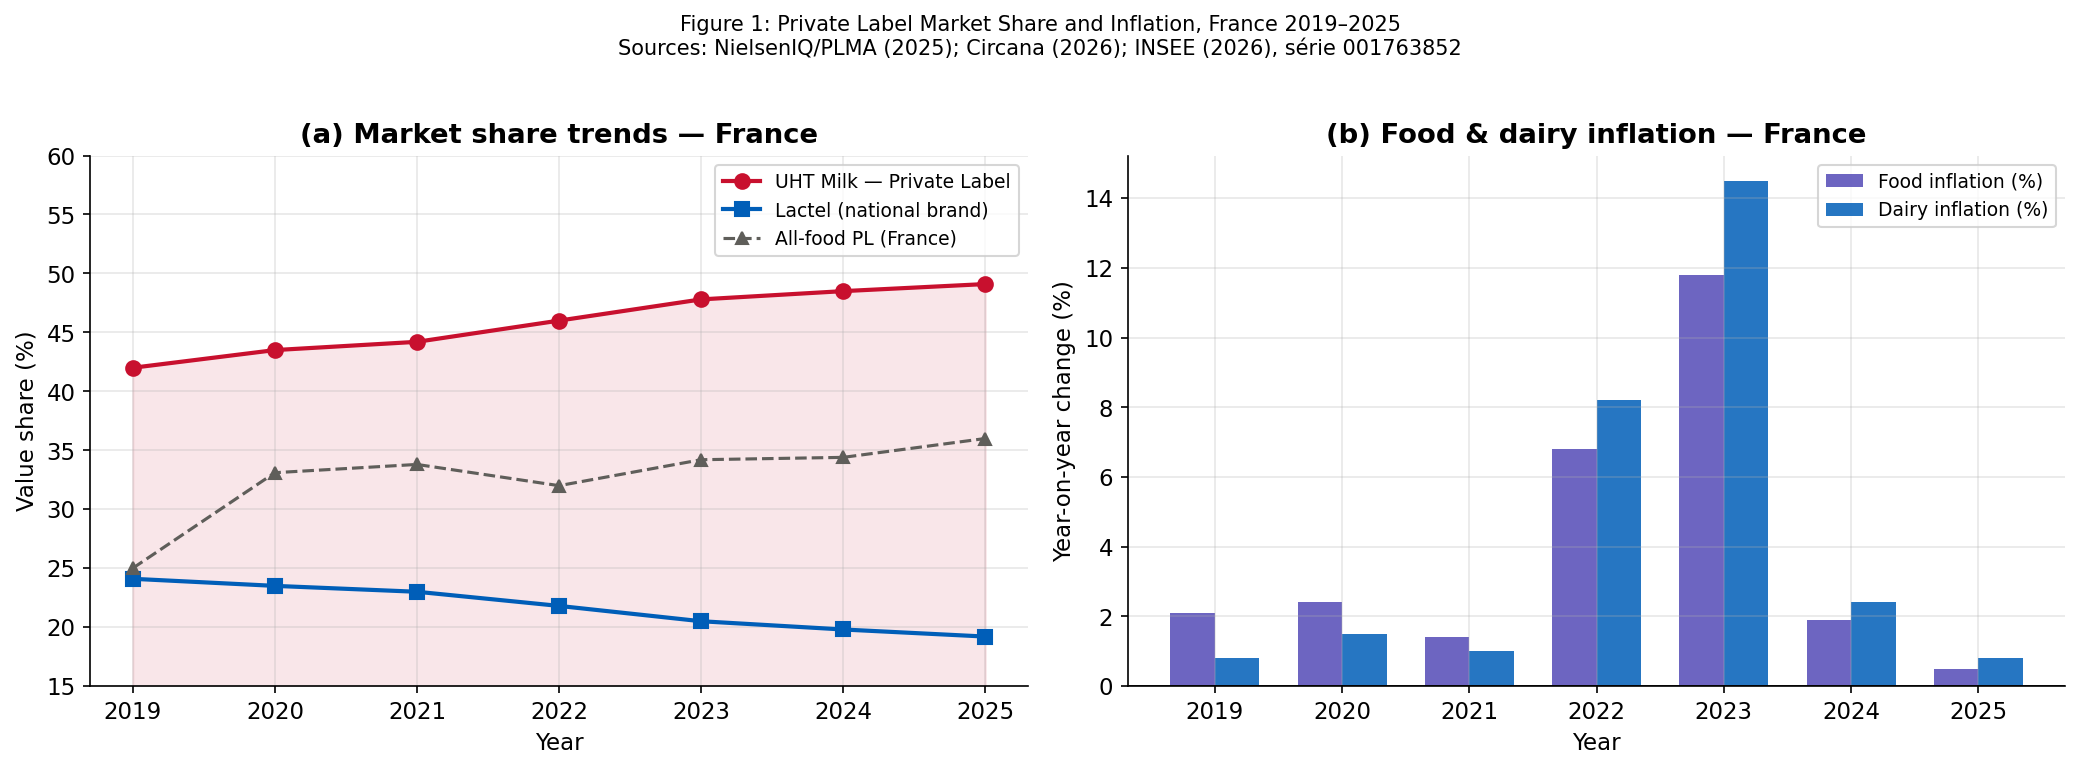

Saved: fig1_market_trends.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(market_data.year, market_data.uht_pl_value_share_pct, alpha=0.10, color=CAR_RED)
ax.plot(market_data.year, market_data.uht_pl_value_share_pct, marker='o', color=CAR_RED,
        lw=2, ms=7, label='UHT Milk — Private Label')
ax.plot(market_data.year, market_data.lactel_value_share_pct,  marker='s', color=LACTEL_BLU,
        lw=2, ms=7, label='Lactel (national brand)')
ax.plot(market_data.year, market_data.pl_value_share_pct,       marker='^', color=NEUTRAL,
        lw=1.5, ms=6, ls='--', label='All-food PL (France)')
ax.set_title('(a) Market share trends — France', fontweight='bold')
ax.set_ylabel('Value share (%)'); ax.set_xlabel('Year')
ax.set_xticks(market_data.year); ax.set_ylim(15, 60); ax.legend(fontsize=9)

ax2 = axes[1]
x, w = np.arange(len(market_data)), 0.35
ax2.bar(x - w/2, market_data.food_inflation_pct,  width=w, color=PURPLE,   alpha=0.85, label='Food inflation (%)')
ax2.bar(x + w/2, market_data.dairy_inflation_pct, width=w, color=LACTEL_BLU, alpha=0.85, label='Dairy inflation (%)')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('(b) Food & dairy inflation — France', fontweight='bold')
ax2.set_ylabel('Year-on-year change (%)'); ax2.set_xlabel('Year')
ax2.set_xticks(x); ax2.set_xticklabels(market_data.year); ax2.legend(fontsize=9)

plt.suptitle(f'Figure 1: Private Label Market Share and Inflation, France 2019–2025\n'
             'Sources: NielsenIQ/PLMA (2025); Circana (2026); INSEE (2026), série 001763852', y=1.02, fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/fig1_market_trends.png'); plt.show()
print('Saved: fig1_market_trends.png')


## 4. European benchmark comparison

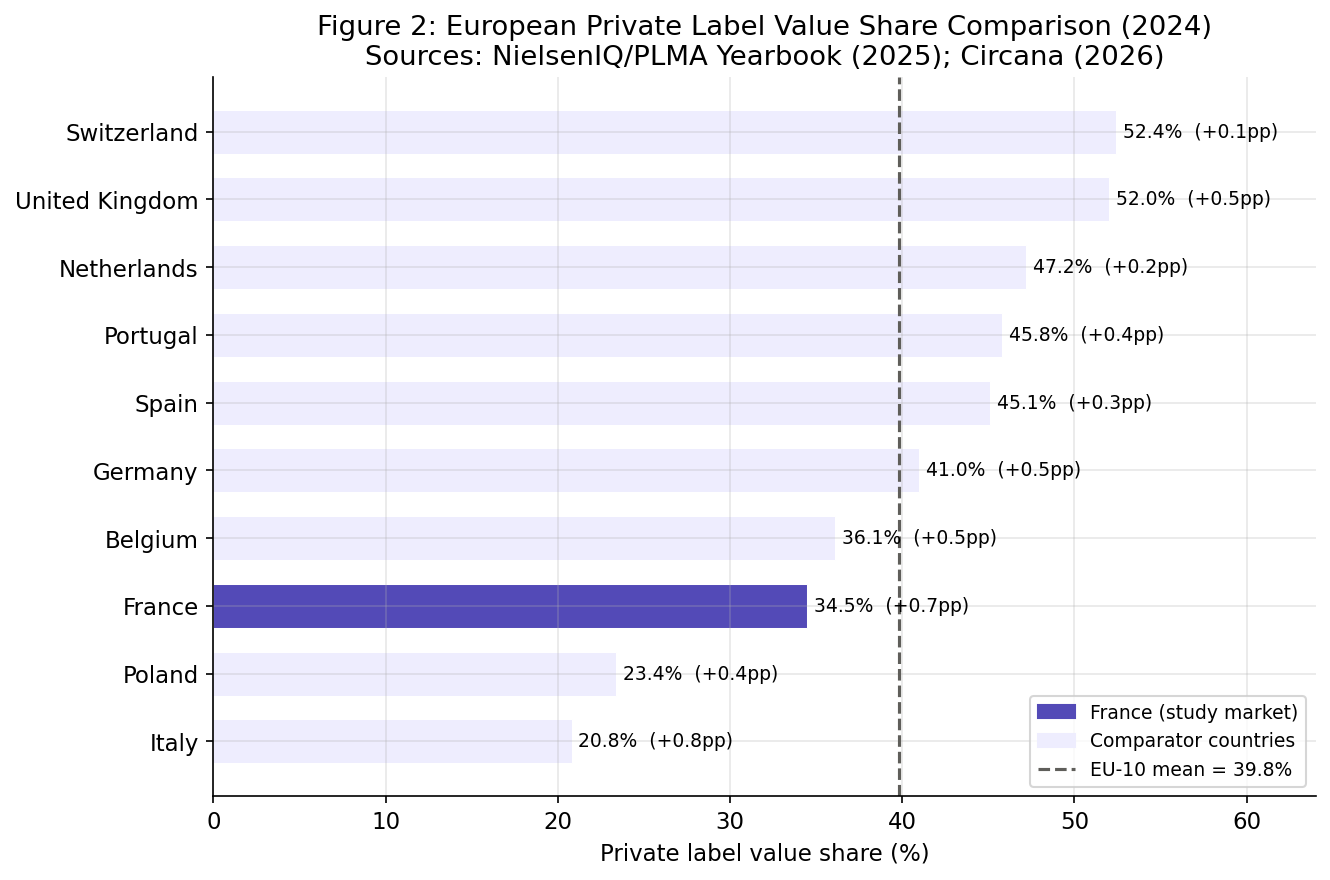

Saved: fig2_european_benchmark.png


In [23]:
europe = pd.DataFrame({
    'country'    : ['Switzerland','United Kingdom','Netherlands','Spain','Portugal',
                    'Germany','Belgium','France','Poland','Italy'],
    'share_2023' : [52.3, 51.5, 47.0, 44.8, 45.4, 40.5, 35.6, 33.8, 23.0, 20.0],
    'share_2024' : [52.4, 52.0, 47.2, 45.1, 45.8, 41.0, 36.1, 34.5, 23.4, 20.8],
}).sort_values('share_2024', ascending=True).reset_index(drop=True)
europe['change_pp'] = (europe['share_2024'] - europe['share_2023']).round(1)
europe.to_csv(f'{OUTDIR}/european_benchmark.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = [PURPLE if c=='France' else LIGHT_PURP for c in europe.country]
bars = ax.barh(europe.country, europe.share_2024, color=colors,
               edgecolor='white', lw=0.5, height=0.65)
for bar, val, chg in zip(bars, europe.share_2024, europe.change_pp):
    ax.text(val+0.4, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%  ({chg:+.1f}pp)', va='center', fontsize=9)
eu_avg = europe.share_2024.mean()
ax.axvline(eu_avg, color=NEUTRAL, ls='--', lw=1.5, label=f'EU-10 mean = {eu_avg:.1f}%')
ax.set_xlabel('Private label value share (%)')
ax.set_xlim(0, 64)
ax.set_title('Figure 2: European Private Label Value Share Comparison (2024)\n'
             'Sources: NielsenIQ/PLMA Yearbook (2025); Circana (2026)')
p1 = mpatches.Patch(color=PURPLE,    label='France (study market)')
p2 = mpatches.Patch(color=LIGHT_PURP, label='Comparator countries')
ax.legend(handles=[p1, p2, plt.Line2D([0],[0], color=NEUTRAL, ls='--',
          label=f'EU-10 mean = {eu_avg:.1f}%')], fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/fig2_european_benchmark.png'); plt.show()
print('Saved: fig2_european_benchmark.png')


## 5. Correlation matrix
Checking how inflation variables relate to private label share (Pearson + Spearman)

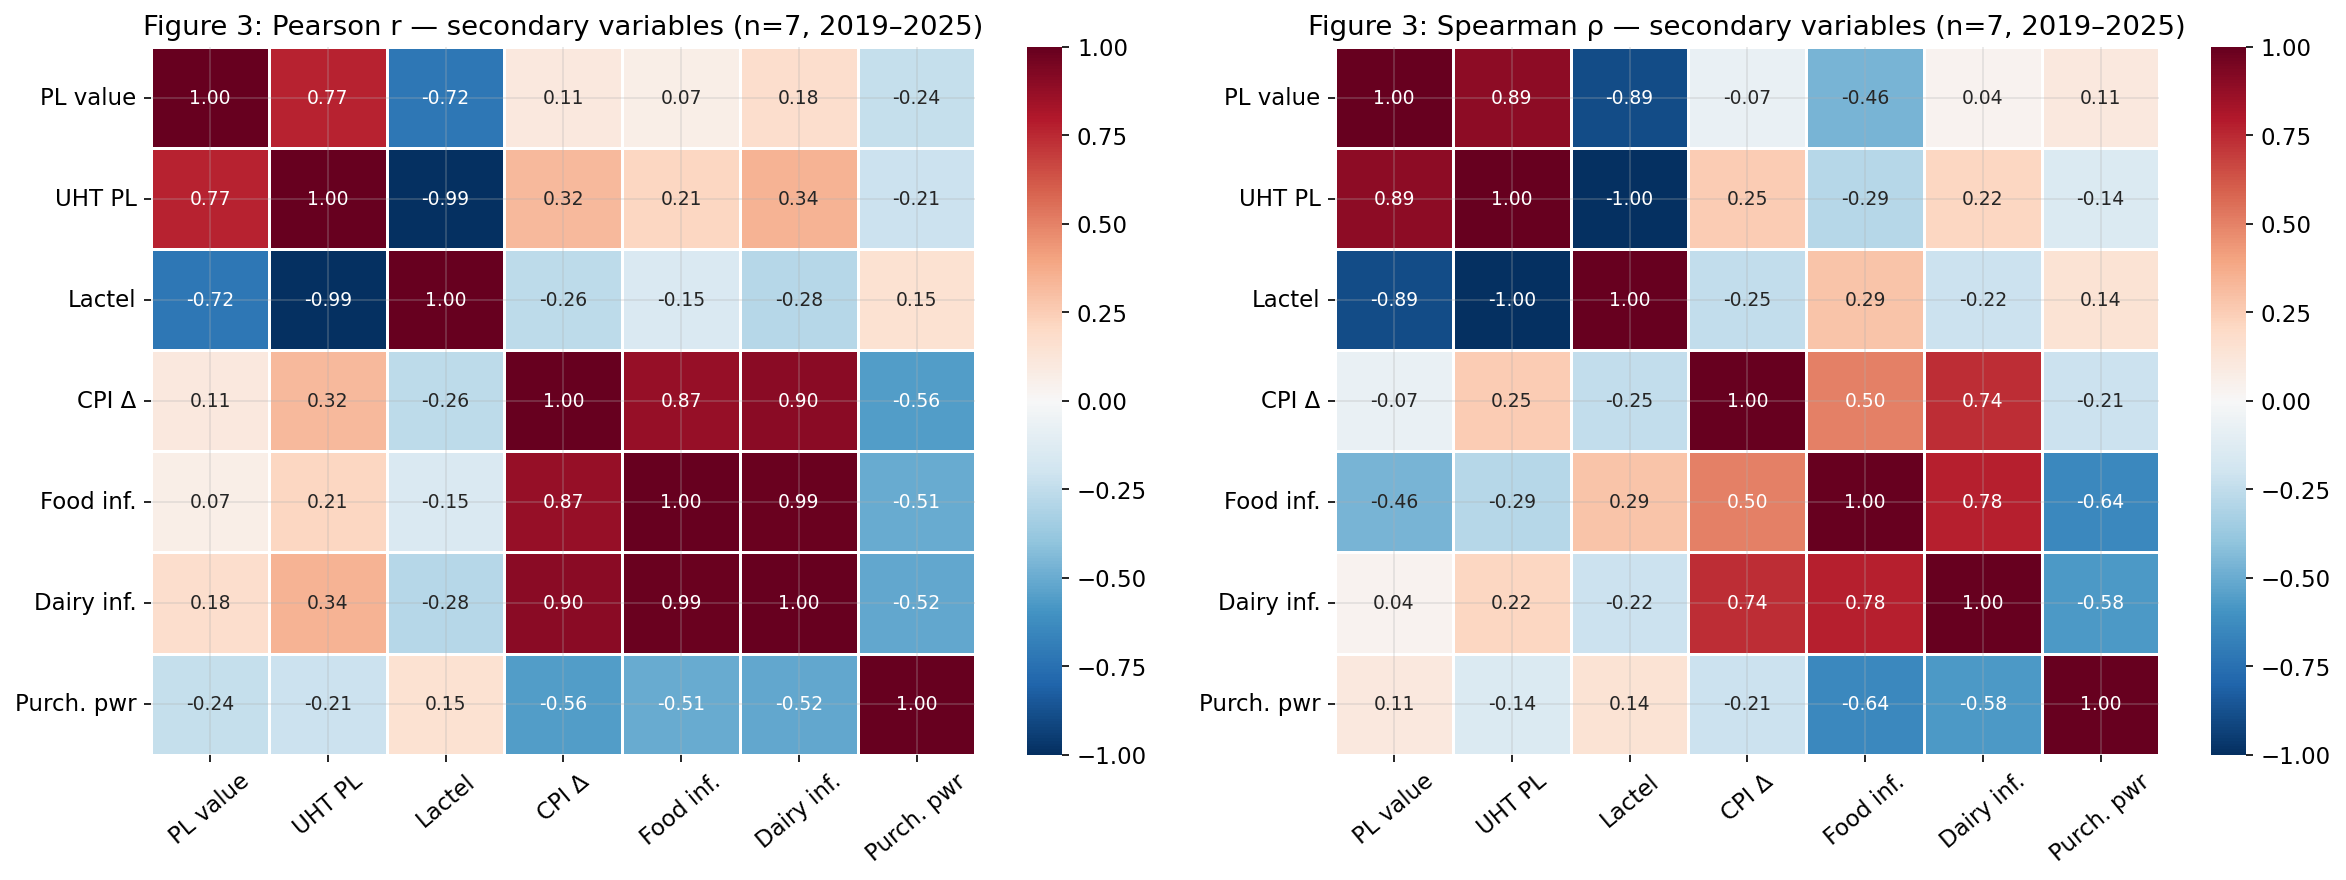

Key result — food inflation → UHT PL share:
  Pearson  r = 0.213,  p = 0.646
  Spearman ρ = -0.286,  p = 0.535


In [24]:
corr_vars = ['pl_value_share_pct','uht_pl_value_share_pct','lactel_value_share_pct',
             'cpi_annual_change_pct','food_inflation_pct','dairy_inflation_pct',
             'household_purchasing_power_pct']
short_lbl = ['PL value','UHT PL','Lactel','CPI Δ','Food inf.','Dairy inf.','Purch. pwr']

pearson  = market_data[corr_vars].corr(method='pearson').round(3)
spearman = market_data[corr_vars].corr(method='spearman').round(3)
pearson.to_csv(f'{OUTDIR}/corr_pearson.csv')
spearman.to_csv(f'{OUTDIR}/corr_spearman.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, mat, title in zip(axes, [pearson, spearman], ['Pearson r', 'Spearman ρ']):
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, linewidths=0.5, linecolor='white',
                xticklabels=short_lbl, yticklabels=short_lbl, annot_kws={'size':9})
    ax.set_title(f'Figure 3: {title} — secondary variables (n=7, 2019–2025)')
    ax.tick_params(axis='x', rotation=40); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/fig3_correlation_matrices.png'); plt.show()

r_p, p_p = stats.pearsonr(market_data['food_inflation_pct'], market_data['uht_pl_value_share_pct'])
r_s, p_s = stats.spearmanr(market_data['food_inflation_pct'], market_data['uht_pl_value_share_pct'])
print(f'Key result — food inflation → UHT PL share:')
print(f'  Pearson  r = {r_p:.3f},  p = {p_p:.3f}')
print(f'  Spearman ρ = {r_s:.3f},  p = {p_s:.3f}')


## 6. OLS Regression — does food inflation drive PL adoption?

Model: UHT_PL_share = β₀ + β₁ × FoodInflation + β₂ × Year

                              OLS Regression Results                              
Dep. Variable:     uht_pl_value_share_pct   R-squared:                       0.994
Model:                                OLS   Adj. R-squared:                  0.991
Method:                     Least Squares   F-statistic:                     342.1
Date:                    Tue, 30 Jun 2026   Prob (F-statistic):           3.38e-05
Time:                            19:43:25   Log-Likelihood:                 1.6129
No. Observations:                       7   AIC:                             2.774
Df Residuals:                           4   BIC:                             2.612
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

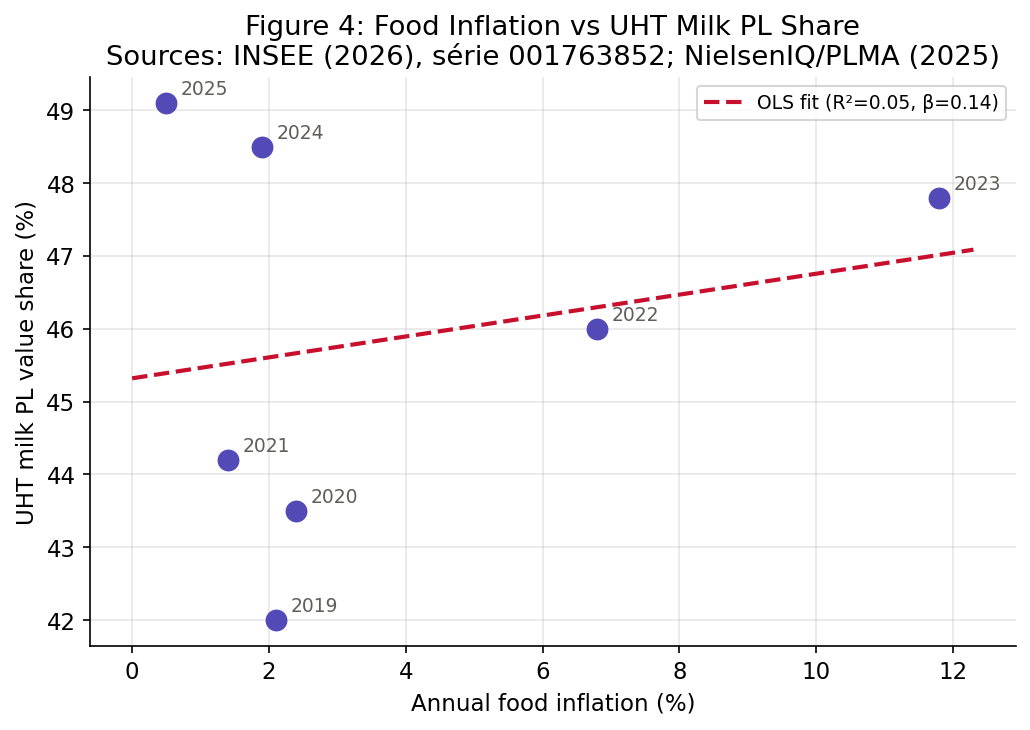

OLS: β=0.144, R²=0.045, p=0.646


In [25]:
mod = ols('uht_pl_value_share_pct ~ food_inflation_pct + year', data=market_data).fit()
print(mod.summary())
with open(f'{OUTDIR}/ols_secondary_summary.txt','w') as f: f.write(mod.summary().as_text())

slope, intercept, r_val, p_val, _ = stats.linregress(
    market_data['food_inflation_pct'], market_data['uht_pl_value_share_pct'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(market_data.food_inflation_pct, market_data.uht_pl_value_share_pct,
           color=PURPLE, s=90, zorder=5)
for _, row in market_data.iterrows():
    ax.annotate(str(int(row.year)), (row.food_inflation_pct, row.uht_pl_value_share_pct),
                textcoords='offset points', xytext=(7,4), fontsize=9, color=NEUTRAL)
x_line = np.linspace(market_data.food_inflation_pct.min()-0.5,
                     market_data.food_inflation_pct.max()+0.5, 100)
ax.plot(x_line, intercept + slope*x_line, color=CAR_RED, lw=2, ls='--',
        label=f'OLS fit (R²={r_val**2:.2f}, β={slope:.2f})')
ax.set_xlabel('Annual food inflation (%)'); ax.set_ylabel('UHT milk PL value share (%)')
ax.set_title('Figure 4: Food Inflation vs UHT Milk PL Share\nSources: INSEE (2026), série 001763852; NielsenIQ/PLMA (2025)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/fig4_ols_scatter.png'); plt.show()
print(f'OLS: β={slope:.3f}, R²={r_val**2:.3f}, p={p_val:.3f}')


## 7. Bootstrap confidence intervals on inflation coefficient
Using 1000 resamples because n=7 years is too small for parametric tests

Bootstrap results (1,000 resamples):
  Mean β  = +0.1190
  95% CI  = [+0.0207, +0.5882]
  Significant (CI excludes 0)? YES


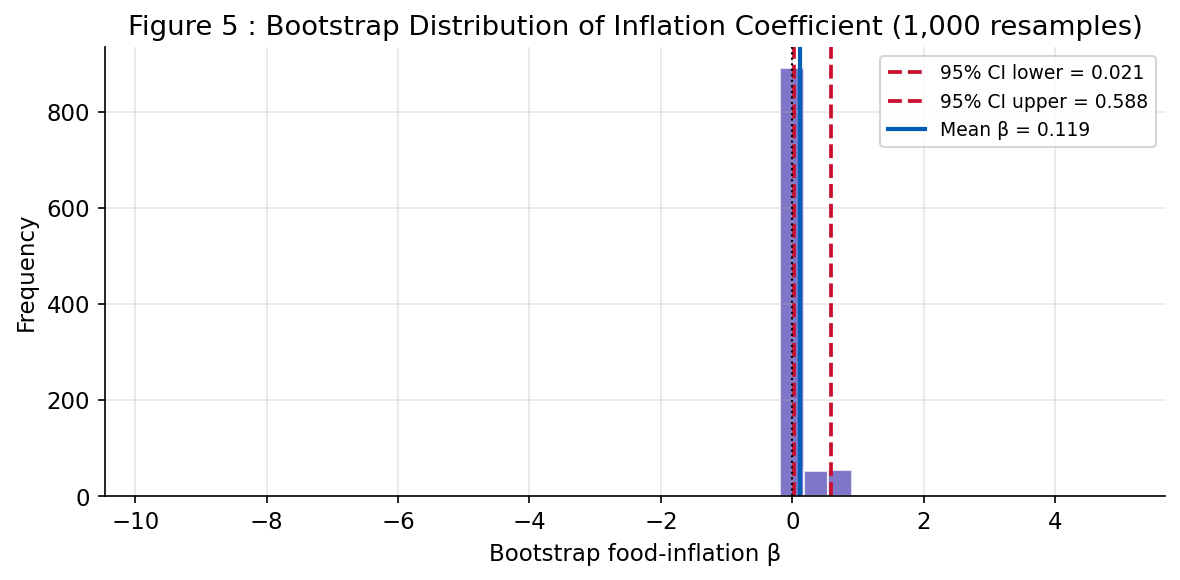

In [26]:
def bootstrap_inflation_coef(df, n_iter=1000, seed=42):
    rng   = np.random.default_rng(seed)
    coefs = []
    for _ in range(n_iter):
        sample = df.sample(frac=1, replace=True,
                           random_state=int(rng.integers(0, 99999)))
        try:
            c = ols('uht_pl_value_share_pct ~ food_inflation_pct + year',
                    data=sample).fit().params['food_inflation_pct']
            coefs.append(c)
        except Exception:
            pass
    return np.array(coefs)

boot    = bootstrap_inflation_coef(market_data, 1000)
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
print(f'Bootstrap results (1,000 resamples):')
print(f'  Mean β  = {boot.mean():+.4f}')
print(f'  95% CI  = [{ci_lo:+.4f}, {ci_hi:+.4f}]')
print(f'  Significant (CI excludes 0)? {"YES" if (ci_lo>0 or ci_hi<0) else "NO"}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot, bins=40, color=PURPLE, alpha=0.75, edgecolor='white')
ax.axvline(ci_lo,       color=CAR_RED,    ls='--', lw=1.8, label=f'95% CI lower = {ci_lo:.3f}')
ax.axvline(ci_hi,       color=CAR_RED,    ls='--', lw=1.8, label=f'95% CI upper = {ci_hi:.3f}')
ax.axvline(0,           color='black',    lw=1.0,  ls=':')
ax.axvline(boot.mean(), color=LACTEL_BLU, lw=2.0,  label=f'Mean β = {boot.mean():.3f}')
ax.set_xlabel('Bootstrap food-inflation β'); ax.set_ylabel('Frequency')
ax.set_title('Figure 5 : Bootstrap Distribution of Inflation Coefficient (1,000 resamples)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/fig5_bootstrap_distribution.png'); plt.show()


---
## PART 2 — PRIMARY SURVEY DATA (n=254)

## 8. Load the survey responses

In [27]:
survey_data = 'primary_data.xlsx'
sur_raw  = pd.read_excel(survey_data)
print(f'Raw survey: {sur_raw.shape[0]} rows × {sur_raw.shape[1]} cols')


Raw survey: 254 rows × 27 cols


## 9. Data cleaning

3 steps: screen Q1, check Likert ranges, check missing values

In [28]:
sur = sur_raw.copy()
print('--- Data cleaning ---')

# STEP 1: Screening filter on Q1
print('\nSTEP 1 — Screening (Q1: purchased milk in last 30 days)')
before = len(sur)
sur = sur[sur['q1_purchased_last30d'].str.contains('Yes', case=False, na=False)].copy()
print(f'  Before: {before} | Removed: {before-len(sur)} non-buyers | Retained: {len(sur)}')

# STEP 2: Likert range validation (Q4–Q20 must be 1–5)
print('\nSTEP 2 — Likert range validation (valid range: 1–5)')
likert_cols = [
    'q4_concerned_lowest_price','q5_quality_primary_factor','q6_compare_prices',
    'q7_carrefour_low_priced_vs_lactel','q8_carrefour_good_value_vs_lactel',
    'q9_rarely_notice_quality_diff','q10_loyal_to_lactel','q11_loyal_to_carrefour',
    'q12_prefer_lactel_even_if_carrefour_cheaper','q13_hard_to_change_usual_brand',
    'q14_easily_notice_carrefour','q15_carrefour_placement_easy_to_spot',
    'q16_notice_carrefour_quicker_than_lactel','q17_carrefour_positioning_influences_choice',
    'q18_intend_purchase_carrefour_next','q19_recommend_carrefour',
    'q20_likely_continue_carrefour_over_lactel'
]
out_of_range = {}
for col in likert_cols:
    bad = sur[(sur[col] < 1) | (sur[col] > 5)]
    if len(bad) > 0: out_of_range[col] = list(bad.index)
if out_of_range:
    print(f'  ⚠ Out-of-range values in {len(out_of_range)} column(s):')
    for col, rows in out_of_range.items():
        print(f'    {col}: {len(rows)} row(s) at index {rows}')
    bad_idx = set(idx for idxs in out_of_range.values() for idx in idxs)
    before = len(sur); sur = sur[~sur.index.isin(bad_idx)].copy()
    print(f'  Removed {before-len(sur)} rows | Retained: {len(sur)}')
else:
    print(f'  ✓ All {len(likert_cols)} Likert columns clean — no values outside [1, 5]')

# STEP 3: Missing value audit
print('\nSTEP 3 — Missing value audit')
missing = sur.isnull().sum(); missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    print('  ⚠ Missing values:'); print(missing_cols)
else:
    print(f'  ✓ No missing values across all {sur.shape[1]} columns')

sur.reset_index(drop=True, inplace=True)
print(f'\nFinal clean sample: n = {len(sur)}')


--- Data cleaning ---

STEP 1 — Screening (Q1: purchased milk in last 30 days)
  Before: 254 | Removed: 0 non-buyers | Retained: 254

STEP 2 — Likert range validation (valid range: 1–5)
  ✓ All 17 Likert columns clean — no values outside [1, 5]

STEP 3 — Missing value audit
  ✓ No missing values across all 27 columns

Final clean sample: n = 254


## 10. Build composite scores

Calculate mean scores for each construct from the Likert items

In [29]:
sur['q9_rev'] = 6 - sur['q9_rarely_notice_quality_diff']

sur['PS']  = sur[['q4_concerned_lowest_price','q6_compare_prices',
                   'q7_carrefour_low_priced_vs_lactel',
                   'q8_carrefour_good_value_vs_lactel']].mean(axis=1)
sur['QC']  = sur[['q5_quality_primary_factor','q9_rev']].mean(axis=1)
sur['BL_L']= sur[['q10_loyal_to_lactel',
                   'q12_prefer_lactel_even_if_carrefour_cheaper',
                   'q13_hard_to_change_usual_brand']].mean(axis=1)
sur['BL_C']= sur['q11_loyal_to_carrefour'].astype(float)
sur['ISV'] = sur[['q14_easily_notice_carrefour','q15_carrefour_placement_easy_to_spot',
                   'q16_notice_carrefour_quicker_than_lactel',
                   'q17_carrefour_positioning_influences_choice']].mean(axis=1)
sur['PIC'] = sur[['q18_intend_purchase_carrefour_next','q19_recommend_carrefour',
                   'q20_likely_continue_carrefour_over_lactel']].mean(axis=1)

sur['DV_carrefour'] = (
    sur['q3_forced_choice_carrefour_lactel'].str.strip().str.lower() == 'carrefour'
).astype(int)

FEATURES    = ['PS','QC','BL_L','BL_C','ISV','PIC']
FEAT_LABELS = ['Price Sensitivity','Quality Concern','Lactel Loyalty',
               'Carrefour Loyalty','In-store Visibility','Purchase Intention']

vc = sur['DV_carrefour'].value_counts()
print(f'Forced choice: Carrefour n={vc.get(1,0)} ({vc.get(1,0)/len(sur)*100:.1f}%) | '
      f'Lactel n={vc.get(0,0)} ({vc.get(0,0)/len(sur)*100:.1f}%)')
print(sur[FEATURES+['DV_carrefour']].describe().round(3).T)


Forced choice: Carrefour n=143 (56.3%) | Lactel n=111 (43.7%)
              count   mean    std  min    25%    50%    75%  max
PS            254.0  3.413  0.835  1.5  2.750  3.500  4.000  5.0
QC            254.0  3.100  0.794  1.0  2.500  3.000  3.500  5.0
BL_L          254.0  3.046  0.871  1.0  2.333  3.000  3.667  5.0
BL_C          254.0  3.157  1.417  1.0  2.000  3.000  4.000  5.0
ISV           254.0  3.207  1.010  1.0  2.500  3.250  4.000  5.0
PIC           254.0  3.178  1.041  1.0  2.333  3.333  4.000  5.0
DV_carrefour  254.0  0.563  0.497  0.0  0.000  1.000  1.000  1.0


## 11. Demographic charts

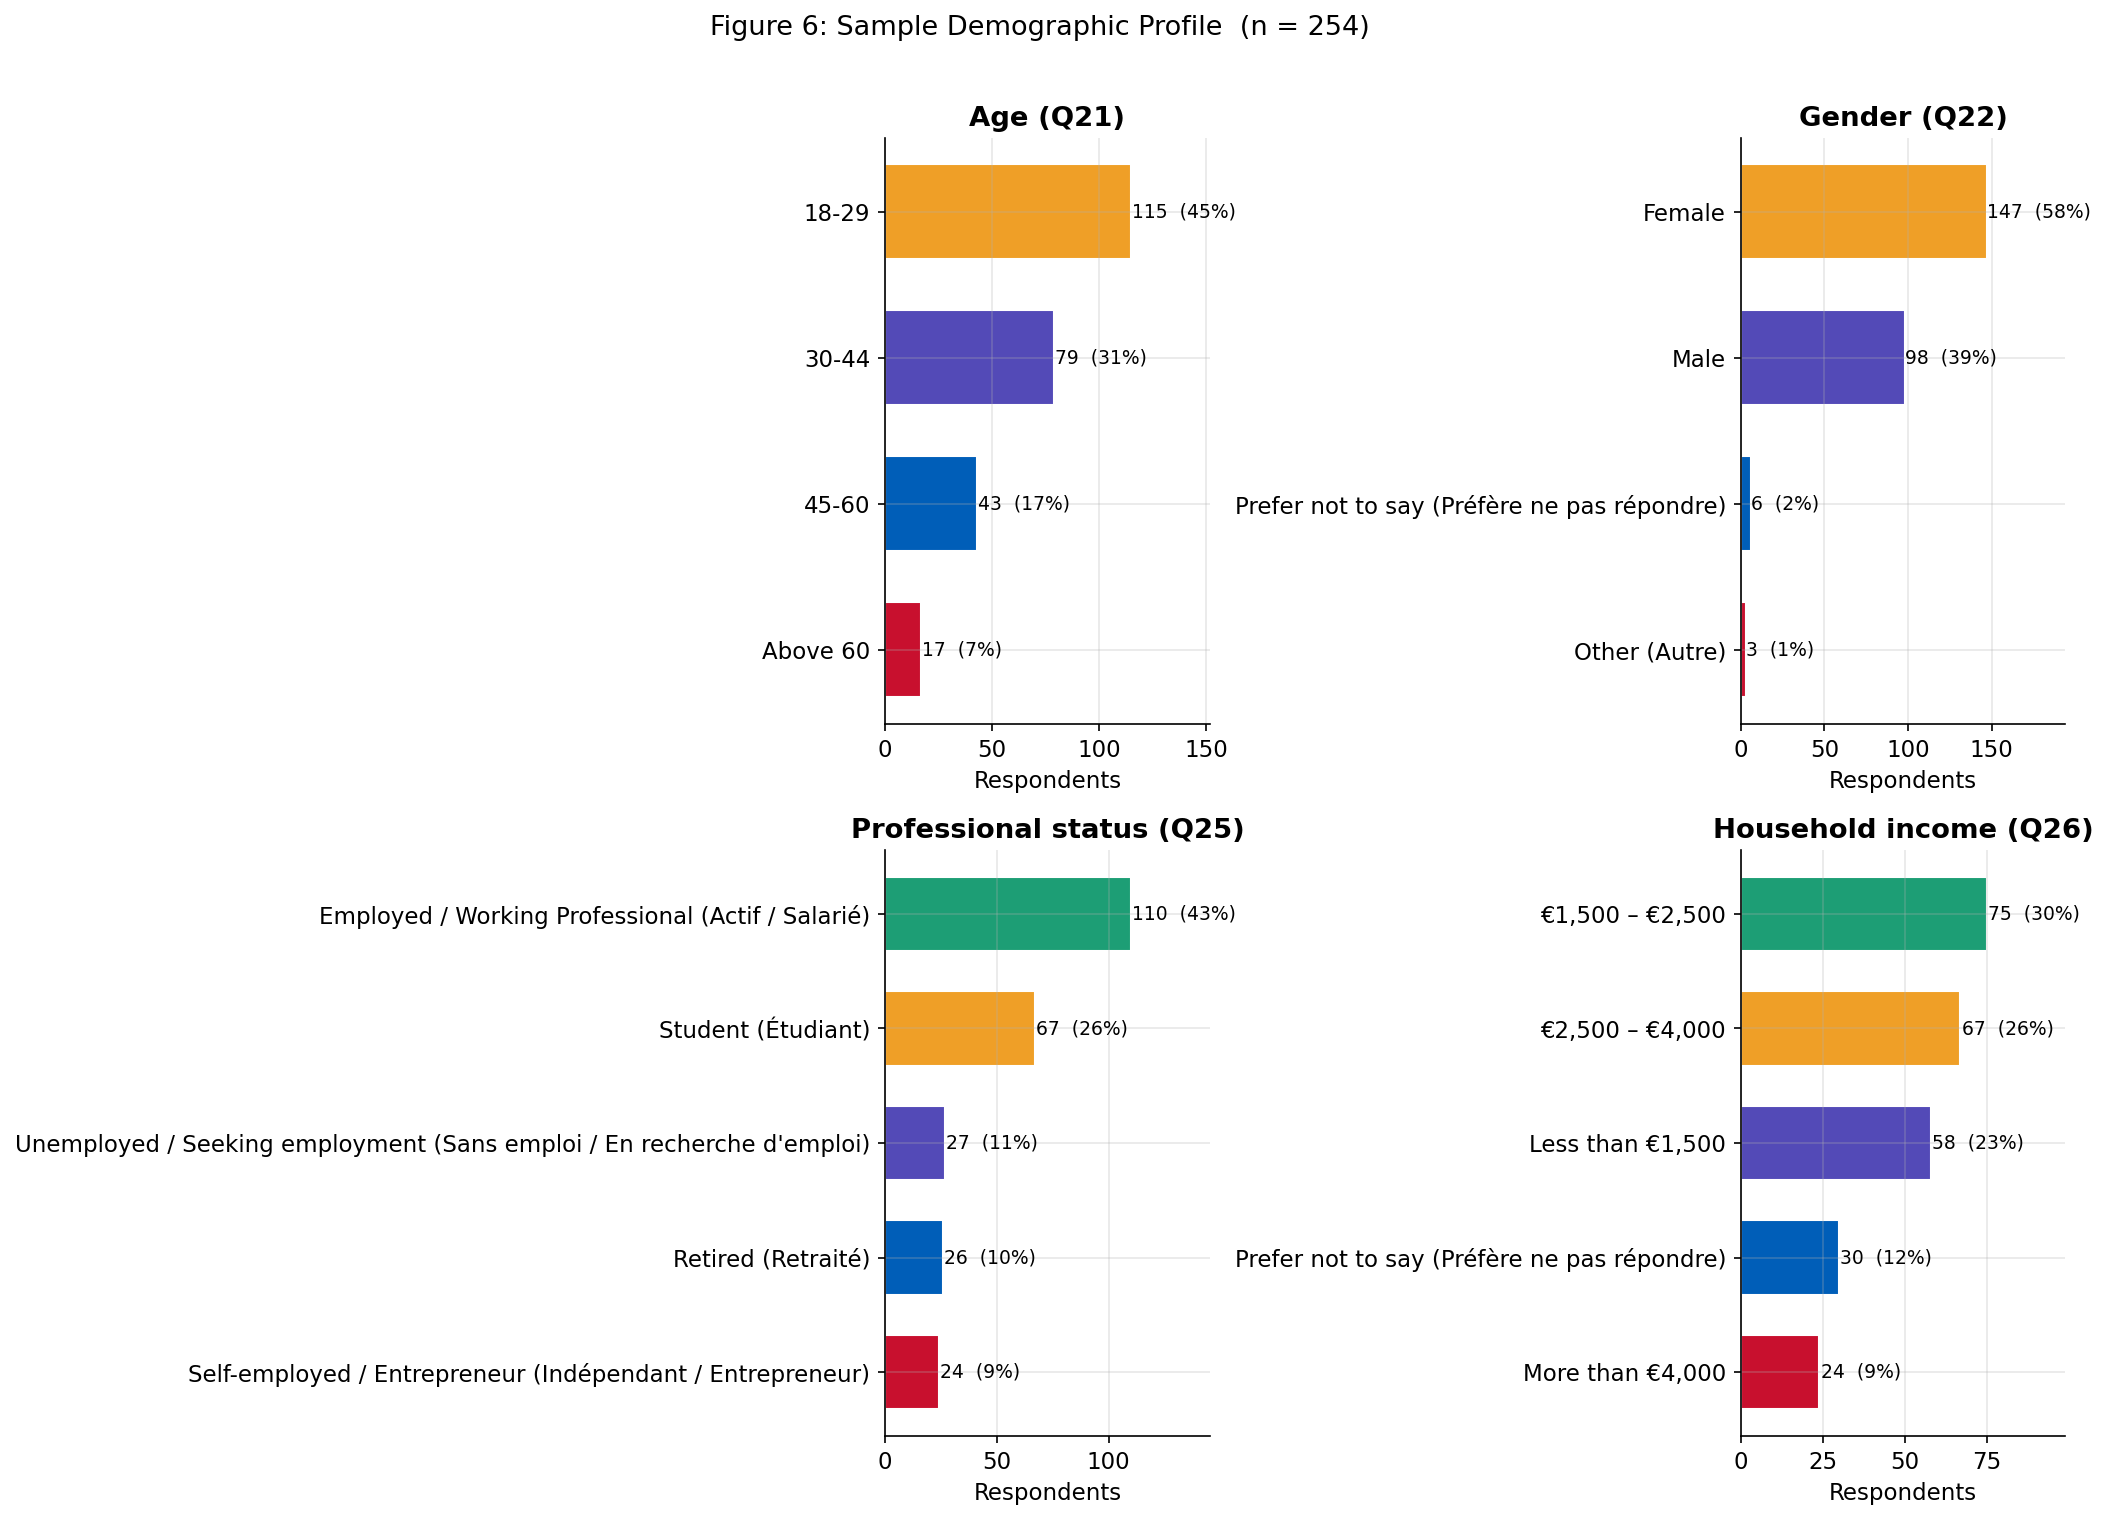

Saved: fig6_demographics.png


In [30]:
demo_map = {'Age (Q21)':'q21_age','Gender (Q22)':'q22_gender',
            'Professional status (Q25)':'q25_professional_status',
            'Household income (Q26)':'q26_income'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (label, col) in zip(axes.flatten(), demo_map.items()):
    counts = sur[col].value_counts().sort_values(ascending=True)
    bars = ax.barh(counts.index.astype(str), counts.values,
                   color=PALETTE_6[:len(counts)], edgecolor='white', height=0.65)
    for bar, val in zip(bars, counts.values):
        ax.text(val+0.4, bar.get_y()+bar.get_height()/2,
                f'{val}  ({val/len(sur)*100:.0f}%)', va='center', fontsize=9)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Respondents')
    ax.set_xlim(0, counts.max()*1.32)

plt.suptitle(f'Figure 6: Sample Demographic Profile  (n = {len(sur)})', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/fig6_demographics.png'); plt.show()
print('Saved: fig6_demographics.png')


## 12. Cronbach's alpha (scale reliability check)

In [31]:
def cronbach_alpha(df_in, items):
    X = df_in[items].dropna()
    k = X.shape[1]
    if k < 2: return np.nan
    item_var  = X.var(axis=0, ddof=1).sum()
    total_var = X.sum(axis=1).var(ddof=1)
    if total_var == 0: return np.nan
    return round((k/(k-1)) * (1 - item_var/total_var), 3)

scale_defs = {
    'Price Sensitivity (PS)'      : ['q4_concerned_lowest_price','q6_compare_prices',
                                      'q7_carrefour_low_priced_vs_lactel',
                                      'q8_carrefour_good_value_vs_lactel'],
    'Quality Concern (QC)'        : ['q5_quality_primary_factor','q9_rev'],
    'Lactel Brand Loyalty (BL_L)' : ['q10_loyal_to_lactel',
                                      'q12_prefer_lactel_even_if_carrefour_cheaper',
                                      'q13_hard_to_change_usual_brand'],
    'In-store Visibility (ISV)'   : ['q14_easily_notice_carrefour',
                                      'q15_carrefour_placement_easy_to_spot',
                                      'q16_notice_carrefour_quicker_than_lactel',
                                      'q17_carrefour_positioning_influences_choice'],
    'Purchase Intention (PIC)'    : ['q18_intend_purchase_carrefour_next',
                                      'q19_recommend_carrefour',
                                      'q20_likely_continue_carrefour_over_lactel'],
}
alpha_rows = []
print(f'{"Construct":<38} {"Items":>6} {"α":>8}  Interpretation')
print('-'*75)
for name, items in scale_defs.items():
    a = cronbach_alpha(sur, items)
    interp = ('Excellent (α≥0.80)' if a>=0.80 else 'Good (α≥0.70)' if a>=0.70
              else 'Acceptable (α≥0.60)' if a>=0.60 else 'Weak')
    print(f'{name:<38} {len(items):>6} {a:>8.3f}  {interp}')
    alpha_rows.append({'construct':name,'n_items':len(items),'alpha':a,'interpretation':interp})
pd.DataFrame(alpha_rows).to_csv(f'{OUTDIR}/cronbach_alpha.csv', index=False)


Construct                               Items        α  Interpretation
---------------------------------------------------------------------------
Price Sensitivity (PS)                      4    0.700  Good (α≥0.70)
Quality Concern (QC)                        2    0.018  Weak
Lactel Brand Loyalty (BL_L)                 3    0.453  Weak
In-store Visibility (ISV)                   4    0.796  Good (α≥0.70)
Purchase Intention (PIC)                    3    0.824  Excellent (α≥0.80)


## 13. Logistic Regression

Predicting who chooses Carrefour vs Lactel. Using statsmodels to get proper p-values and odds ratios.

In [32]:
scaler   = StandardScaler()
Z_scaled = scaler.fit_transform(sur[FEATURES])
Z_df     = pd.DataFrame(Z_scaled, columns=FEATURES, index=sur.index)

X_sm = sm.add_constant(Z_df)
y_sm = sur['DV_carrefour']

logit_mod = sm.Logit(y_sm, X_sm).fit(disp=False)
print(logit_mod.summary())
with open(f'{OUTDIR}/logit_summary.txt','w') as f: f.write(logit_mod.summary().as_text())

or_df = pd.DataFrame({
    'Construct' : FEAT_LABELS,
    'β'         : logit_mod.params[1:].round(3).values,
    'OR'        : np.exp(logit_mod.params[1:]).round(3).values,
    'OR_CI_low' : np.exp(logit_mod.conf_int().iloc[1:,0]).round(3).values,
    'OR_CI_high': np.exp(logit_mod.conf_int().iloc[1:,1]).round(3).values,
    'p_value'   : logit_mod.pvalues[1:].round(4).values,
    'Sig'       : ['**' if p<0.01 else ('*' if p<0.05 else ('†' if p<0.10 else 'n.s.'))
                   for p in logit_mod.pvalues[1:]]
})
or_df.to_csv(f'{OUTDIR}/logit_odds_ratios.csv', index=False)
print('\nOdds Ratios:'); print(or_df.to_string(index=False))


                           Logit Regression Results                           
Dep. Variable:           DV_carrefour   No. Observations:                  254
Model:                          Logit   Df Residuals:                      247
Method:                           MLE   Df Model:                            6
Date:                Tue, 30 Jun 2026   Pseudo R-squ.:                  0.1421
Time:                        19:43:50   Log-Likelihood:                -149.31
converged:                       True   LL-Null:                       -174.04
Covariance Type:            nonrobust   LLR p-value:                 6.032e-09
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3057      0.141      2.171      0.030       0.030       0.582
PS             0.1683      0.180      0.933      0.351      -0.185       0.522
QC            -0.1453      0.159     -0.914      0.3

### 13a. VIF check for multicollinearity

In [33]:
vif_df = pd.DataFrame({
    'Feature'  : FEATURES, 'Construct': FEAT_LABELS,
    'VIF'      : [round(variance_inflation_factor(X_sm.values, i+1), 2) for i in range(len(FEATURES))]
})
vif_df['Flag'] = vif_df['VIF'].apply(
    lambda v: 'OK (<5)' if v<5 else ('Moderate (5–10)' if v<10 else '⚠ HIGH >10'))
vif_df.to_csv(f'{OUTDIR}/vif_diagnostics.csv', index=False)
print('VIF Diagnostics:')
print(vif_df.to_string(index=False))


VIF Diagnostics:
Feature           Construct  VIF    Flag
     PS   Price Sensitivity 1.70 OK (<5)
     QC     Quality Concern 1.29 OK (<5)
   BL_L      Lactel Loyalty 1.24 OK (<5)
   BL_C   Carrefour Loyalty 2.15 OK (<5)
    ISV In-store Visibility 1.28 OK (<5)
    PIC  Purchase Intention 2.20 OK (<5)


### 13b. Cross-validation + confusion matrix + coefficient plot

5-Fold CV Accuracy: 0.638 ± 0.077
5-Fold CV ROC-AUC:  0.724 ± 0.072


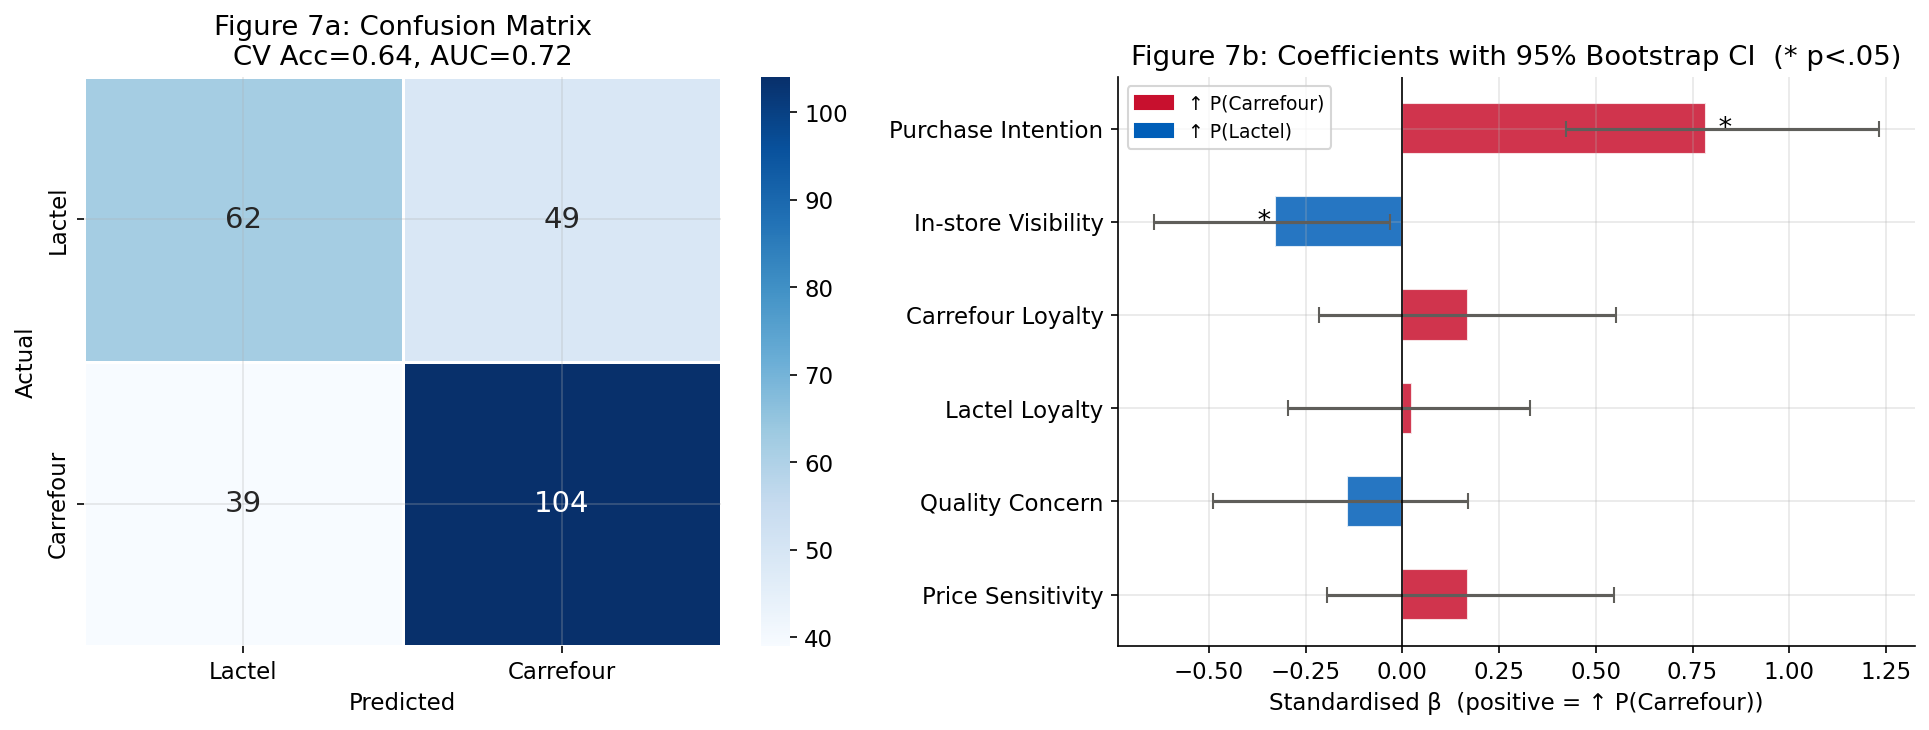

In [34]:
y_arr = sur['DV_carrefour'].values
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf   = LogisticRegression(max_iter=2000, random_state=42)

cv_acc = cross_val_score(clf, Z_scaled, y_arr, cv=cv, scoring='accuracy')
cv_auc = cross_val_score(clf, Z_scaled, y_arr, cv=cv, scoring='roc_auc')
print(f'5-Fold CV Accuracy: {cv_acc.mean():.3f} ± {cv_acc.std():.3f}')
print(f'5-Fold CV ROC-AUC:  {cv_auc.mean():.3f} ± {cv_auc.std():.3f}')

clf.fit(Z_scaled, y_arr)
cm = confusion_matrix(y_arr, clf.predict(Z_scaled))

np.random.seed(42)
boot_coefs = []
for _ in range(1000):
    idx = np.random.choice(len(Z_scaled), len(Z_scaled), replace=True)
    lrb = LogisticRegression(max_iter=2000, random_state=0)
    lrb.fit(Z_scaled[idx], y_arr[idx]); boot_coefs.append(lrb.coef_[0])
boot_coefs = np.array(boot_coefs)
ci_lo_b = np.percentile(boot_coefs, 2.5, axis=0)
ci_hi_b = np.percentile(boot_coefs, 97.5, axis=0)
coefs    = clf.coef_[0]
sig_mask = [(l>0 or h<0) for l,h in zip(ci_lo_b, ci_hi_b)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Lactel','Carrefour'], yticklabels=['Lactel','Carrefour'],
            lw=0.5, linecolor='white', annot_kws={'size':14})
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title(f'Figure 7a: Confusion Matrix\nCV Acc={cv_acc.mean():.2f}, AUC={cv_auc.mean():.2f}')

bar_cols = [CAR_RED if c>0 else LACTEL_BLU for c in coefs]
axes[1].barh(FEAT_LABELS, coefs, color=bar_cols, alpha=0.85, edgecolor='white', height=0.55)
axes[1].errorbar(coefs, range(len(coefs)),
                 xerr=[coefs-ci_lo_b, ci_hi_b-coefs],
                 fmt='none', color=NEUTRAL, lw=1.5, capsize=4)
for i, (sig, coef) in enumerate(zip(sig_mask, coefs)):
    if sig:
        axes[1].text(coef+(0.01 if coef>0 else -0.01), i, ' *',
                     va='center', ha='left' if coef>0 else 'right', fontsize=13)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Standardised β  (positive = ↑ P(Carrefour))')
axes[1].set_title('Figure 7b: Coefficients with 95% Bootstrap CI  (* p<.05)')
p1 = mpatches.Patch(color=CAR_RED,    label='↑ P(Carrefour)')
p2 = mpatches.Patch(color=LACTEL_BLU, label='↑ P(Lactel)')
axes[1].legend(handles=[p1,p2], fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/fig7_logistic_regression.png'); plt.show()


## 14. K-means clustering (consumer segmentation)

Testing k=2 to 6, using elbow method and silhouette score to pick the best k

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x786e5a1f28e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/scikit_learn.libs/libgomp-a34b3233.so.

   k     Inertia    Silhouette
--------------------------------
   2      1068.9         0.255  ← best sil.
   3       919.8         0.208
   4       825.2         0.182
   5       762.1         0.171
   6       701.4         0.166

Best k by Silhouette: 2  → Adopting k=3 (Ong & Prasetyo, 2023)


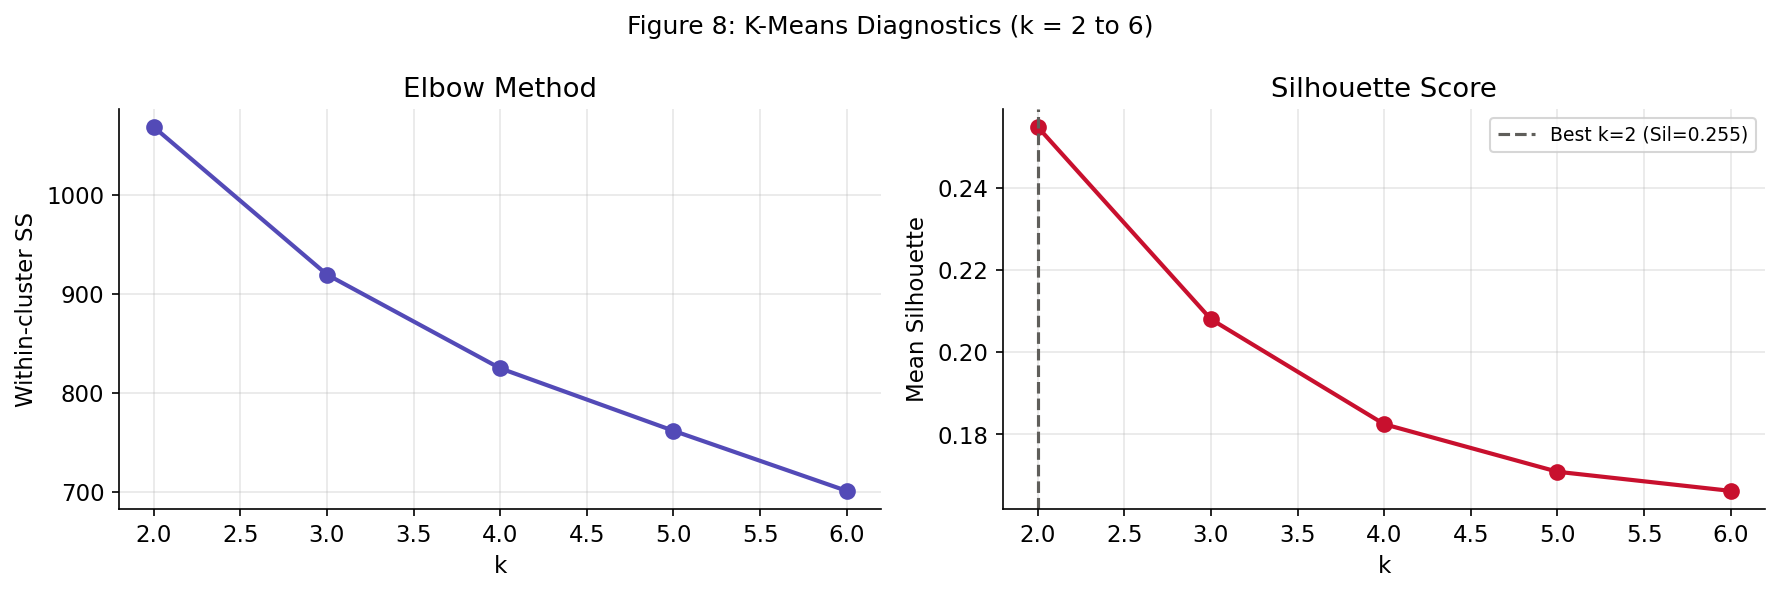

In [35]:
Z = StandardScaler().fit_transform(sur[FEATURES])
inertias, sils = [], []
K_RANGE = range(2, 7)
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=25, random_state=42).fit(Z)
    inertias.append(km.inertia_); sils.append(silhouette_score(Z, km.labels_))

print(f'{"k":>4}  {"Inertia":>10}  {"Silhouette":>12}')
print('-'*32)
for k, ine, sil in zip(K_RANGE, inertias, sils):
    flag = '  ← best sil.' if sil==max(sils) else ''
    print(f'{k:>4}  {ine:>10.1f}  {sil:>12.3f}{flag}')
best_k_sil = list(K_RANGE)[sils.index(max(sils))]
print(f'\nBest k by Silhouette: {best_k_sil}  → Adopting k=3 (Ong & Prasetyo, 2023)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-', color=PURPLE, lw=2, ms=7)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Within-cluster SS'); axes[0].set_title('Elbow Method')
axes[1].plot(list(K_RANGE), sils, 'o-', color=CAR_RED, lw=2, ms=7)
axes[1].axvline(best_k_sil, color=NEUTRAL, ls='--', label=f'Best k={best_k_sil} (Sil={max(sils):.3f})')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Mean Silhouette'); axes[1].set_title('Silhouette Score')
axes[1].legend(fontsize=9)
plt.suptitle('Figure 8: K-Means Diagnostics (k = 2 to 6)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/fig8_kmeans_diagnostics.png'); plt.show()


### 14a. Fit k=3 and profile the segments

In [36]:
km3 = KMeans(n_clusters=3, n_init=50, random_state=42).fit(Z)
sur['segment'] = km3.labels_

profile = sur.groupby('segment')[FEATURES+['DV_carrefour']].mean().round(3)
profile['n']             = sur.groupby('segment').size()
profile['pct_carrefour'] = (profile['DV_carrefour']*100).round(1)
profile['pct_lactel']    = (100-profile['pct_carrefour']).round(1)
profile.to_csv(f'{OUTDIR}/segment_profile.csv')

seg_order = profile['pct_lactel'].sort_values().index.tolist()
seg_names = {seg_order[0]:'Seg A — Value Seekers',
             seg_order[1]:'Seg B — Pragmatists',
             seg_order[2]:'Seg C — NB Loyalists'}
sur['seg_label'] = sur['segment'].map(seg_names)

print('=== Segment Profiles (k=3) ===')
print(profile.to_string())

for label, col in [('Age','q21_age'),('Income','q26_income'),('Gender','q22_gender')]:
    ct = pd.crosstab(sur['seg_label'], sur[col], normalize='index').round(3).mul(100)
    ct.to_csv(f'{OUTDIR}/segment_x_{label.lower()}.csv')
    print(f'\n=== Segment × {label} (%) ==='); print(ct.to_string())


=== Segment Profiles (k=3) ===
            PS     QC   BL_L   BL_C    ISV    PIC  DV_carrefour    n  pct_carrefour  pct_lactel
segment                                                                                        
0        3.991  2.943  3.041  4.142  3.868  4.022         0.670  106           67.0        33.0
1        2.747  3.775  3.529  1.738  2.928  2.262         0.400   80           40.0        60.0
2        3.298  2.551  2.485  3.294  2.504  2.941         0.588   68           58.8        41.2

=== Segment × Age (%) ===
q21_age                18-29  30-44  45-60  Above 60
seg_label                                           
Seg A — Value Seekers   43.4   38.7   13.2       4.7
Seg B — Pragmatists     45.6   20.6   19.1      14.7
Seg C — NB Loyalists    47.5   30.0   20.0       2.5

=== Segment × Income (%) ===
q26_income             Less than €1,500  More than €4,000  Prefer not to say (Préfère ne pas répondre)  €1,500 – €2,500  €2,500 – €4,000
seg_label                     

### 14b. Visualise segments — radar, heatmap, choice split

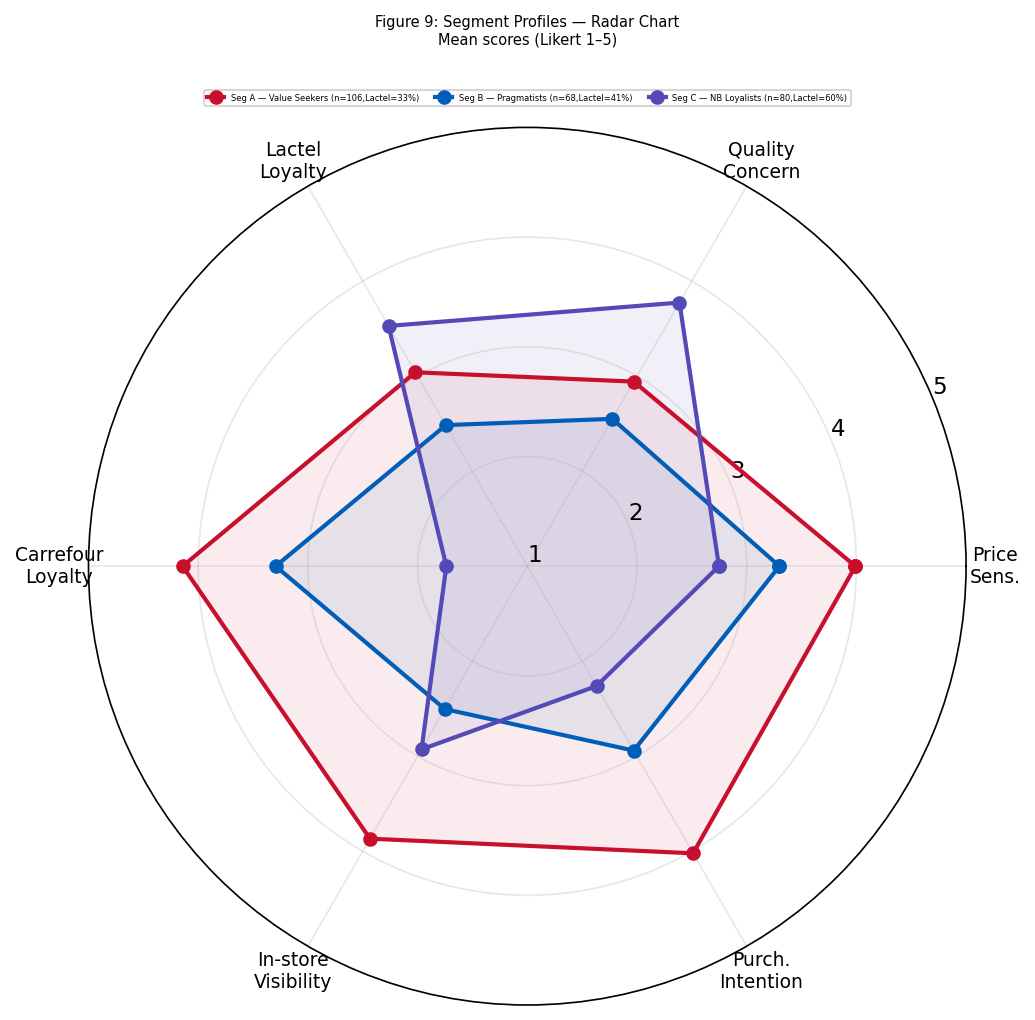

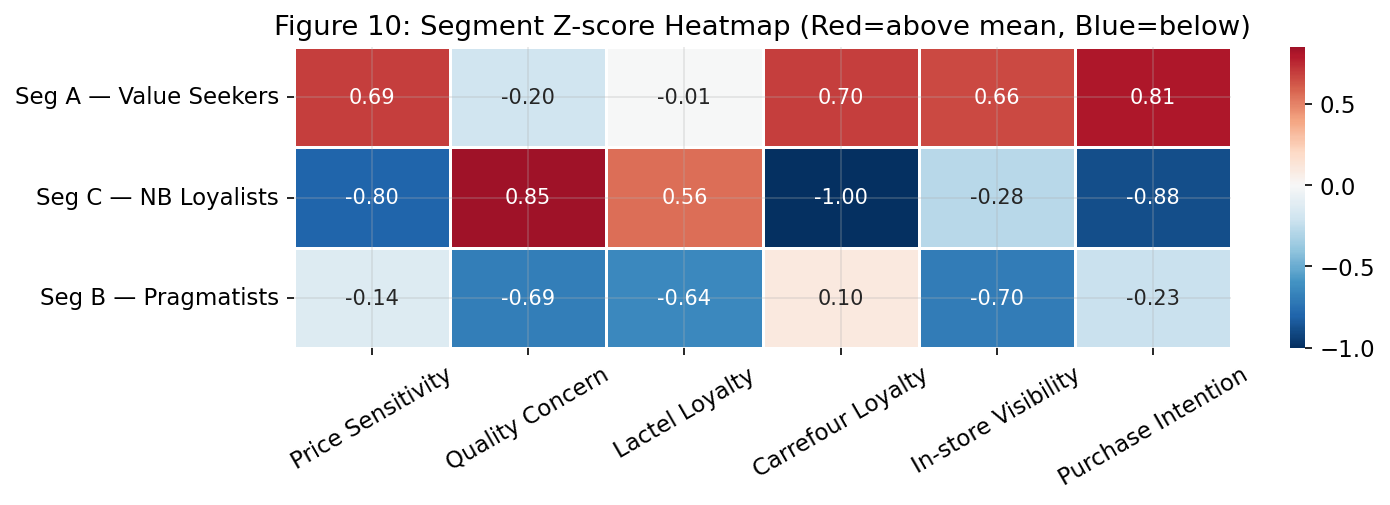

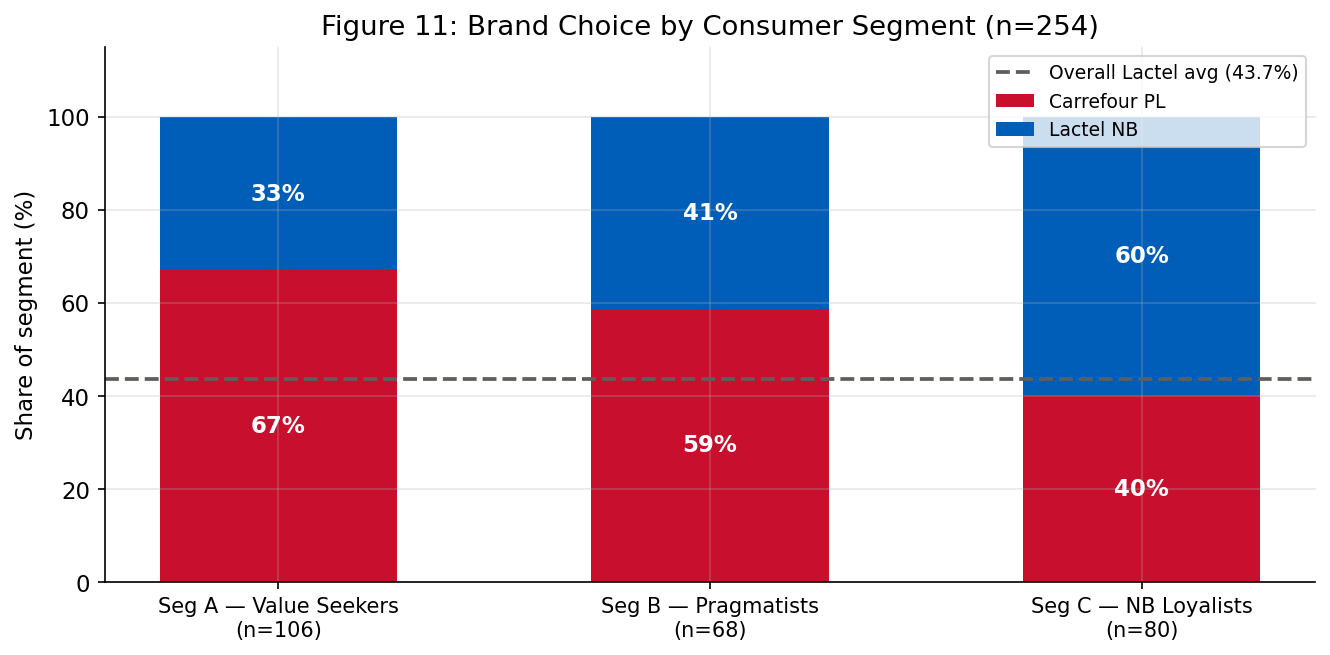

In [37]:
SEG_COLORS = [CAR_RED, LACTEL_BLU, PURPLE]
radar_lbl  = ['Price\nSens.','Quality\nConcern','Lactel\nLoyalty',
              'Carrefour\nLoyalty','In-store\nVisibility','Purch.\nIntention']

# Figure 9: Radar
N_f    = len(FEATURES)
angles = [n/float(N_f)*2*np.pi for n in range(N_f)] + [0]
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
for seg_id, col in zip(seg_order, SEG_COLORS):
    vals = profile.loc[seg_id, FEATURES].tolist() + [profile.loc[seg_id, FEATURES[0]]]
    ax.plot(angles, vals, 'o-', lw=2, color=col,
            label=f'{seg_names[seg_id]} (n={int(profile.loc[seg_id,"n"])},Lactel={profile.loc[seg_id,"pct_lactel"]:.0f}%)') # Removed line break and adjusted spacing for conciseness
    ax.fill(angles, vals, alpha=0.08, color=col)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_lbl, size=9)
ax.set_ylim(1,5); ax.set_yticks([1,2,3,4,5])
ax.set_title('Figure 9: Segment Profiles — Radar Chart\nMean scores (Likert 1–5)', pad=40, fontsize=7)
ax.legend(loc='lower center', bbox_to_anchor=(0.5,1.02), fontsize=4, ncol=3)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/fig9_segment_radar.png'); plt.show()

# Figure 10: Z-score heatmap
seg_z = (pd.DataFrame(Z, columns=FEATURES).assign(segment=km3.labels_)
           .groupby('segment').mean())
seg_z.index = [seg_names[i] for i in seg_z.index]
fig, ax = plt.subplots(figsize=(10,3.5))
sns.heatmap(seg_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            lw=0.5, linecolor='white', ax=ax,
            xticklabels=FEAT_LABELS, yticklabels=seg_z.index, annot_kws={'size':10})
ax.set_title('Figure 10: Segment Z-score Heatmap (Red=above mean, Blue=below)')
ax.tick_params(axis='x', rotation=30); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/fig10_segment_heatmap.png'); plt.show()

# Figure 11: Choice split by segment
seg_choice = profile.loc[seg_order, ['pct_carrefour','pct_lactel','n']].copy()
seg_choice.index = [seg_names[i] for i in seg_choice.index]
fig, ax = plt.subplots(figsize=(9,4.5))
x = np.arange(len(seg_choice))
ax.bar(x, seg_choice['pct_carrefour'], color=CAR_RED,    label='Carrefour PL', width=0.55)
ax.bar(x, seg_choice['pct_lactel'],    color=LACTEL_BLU, label='Lactel NB',
       bottom=seg_choice['pct_carrefour'], width=0.55)
overall_lactel = (1-sur['DV_carrefour'].mean())*100
ax.axhline(overall_lactel, color=NEUTRAL, ls='--', lw=1.8,
           label=f'Overall Lactel avg ({overall_lactel:.1f}%)')
for i, (_, row) in enumerate(seg_choice.iterrows()):
    ax.text(i, row['pct_carrefour']/2, f"{row['pct_carrefour']:.0f}%",
            ha='center', va='center', color='white', fontsize=11, fontweight='bold')
    ax.text(i, row['pct_carrefour']+row['pct_lactel']/2, f"{row['pct_lactel']:.0f}%",
            ha='center', va='center', color='white', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{s}\n(n={int(r.n)})' for s,r in seg_choice.iterrows()], fontsize=10)
ax.set_ylabel('Share of segment (%)'); ax.set_ylim(0,115)
ax.set_title('Figure 11: Brand Choice by Consumer Segment (n=254)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/fig11_choice_by_segment.png'); plt.show()

---
## 15. Bridge test

Comparing the survey result (56.3% chose Carrefour) against the national PL benchmark (34.4%) using a two-proportion z-test

In [38]:
bench_row = bench[bench['metric'].str.contains('Secondary', case=False)].iloc[0]
bench_pct = float(bench_row['value_pct']) / 100

n_survey = len(sur)
k_survey = int(sur['DV_carrefour'].sum())
p_survey = k_survey / n_survey

z_stat, p_val = proportions_ztest(count=k_survey, nobs=n_survey, value=bench_pct)

sig = ('*** p<0.001' if p_val<0.001 else '** p<0.01' if p_val<0.01
       else '* p<0.05' if p_val<0.05 else 'n.s.')

print('='*60)
print('BRIDGE TEST: Two-Proportion z-test')
print('='*60)
print(f'  National PL benchmark (secondary)  = {bench_pct*100:.1f}%')
print(f'  Survey Carrefour share (n={n_survey})   = {p_survey*100:.1f}%')
print(f'  Difference                         = {(p_survey-bench_pct)*100:+.1f} pp')
print(f'  z = {z_stat:.3f},  p = {p_val:.4g}  →  {sig}')
print(f'  INSEE data source: valeurs_mensuelles.csv (series 001763852)')


BRIDGE TEST: Two-Proportion z-test
  National PL benchmark (secondary)  = 34.4%
  Survey Carrefour share (n=254)   = 56.3%
  Difference                         = +21.9 pp
  z = 7.036,  p = 1.973e-12  →  *** p<0.001
  INSEE data source: valeurs_mensuelles.csv (series 001763852)


## 16. Save all outputs

In [39]:
sur.to_csv(f'{OUTDIR}/survey_clean.csv', index=False)
market_data.to_csv(f'{OUTDIR}/secondary_clean.csv', index=False)
europe.to_csv(f'{OUTDIR}/european_benchmark.csv', index=False)

# Record data provenance
provenance = {
    'INSEE_file': 'valeurs_mensuelles.csv',
    'INSEE_series': '001763852',
    'secondary_excel': 'secondary_data.xlsx',
    'survey_file': 'milk_survey_responses-3.xlsx',
    'survey_n_final': len(sur),
    'analysis_date': pd.Timestamp.now().strftime('%Y-%m-%d'),
}
pd.DataFrame([provenance]).to_csv(f'{OUTDIR}/data_provenance.csv', index=False)

print('✓ All outputs saved to:', os.path.abspath(OUTDIR))
print()
for fname in sorted(os.listdir(OUTDIR)):
    fpath = os.path.join(OUTDIR, fname)
    print(f'  {fname:<52}  {os.path.getsize(fpath):>10,} bytes')


✓ All outputs saved to: /content/outputs

  corr_pearson.csv                                             607 bytes
  corr_spearman.csv                                            605 bytes
  cronbach_alpha.csv                                           266 bytes
  data_provenance.csv                                          178 bytes
  european_benchmark.csv                                       270 bytes
  fig10_segment_heatmap.png                                150,612 bytes
  fig11_choice_by_segment.png                               92,806 bytes
  fig1_market_trends.png                                   171,928 bytes
  fig2_european_benchmark.png                              167,038 bytes
  fig3_correlation_matrices.png                            265,358 bytes
  fig4_ols_scatter.png                                     106,871 bytes
  fig5_bootstrap_distribution.png                           76,987 bytes
  fig6_demographics.png                                    267,563 bytes
  fig7_lo

---
## References / Data Sources

The main sources for the secondary data:

- **INSEE** (2026) — CPI series 001763852. https://www.insee.fr/fr/statistiques/serie/001763852
- **NielsenIQ / PLMA** (2025) — International Private Label Yearbook
- **Circana** (2026) — Private label in Europe report
- **Carrefour Group** (2026) — Annual report / Carrefour 2030 plan
- **Lactalis Group** (2025) — Key figures. https://www.lactalis.com
- **McKinsey & Company** (2024) — A turning point for private brands
- **Eurostat** (2026) — HICP France. https://ec.europa.eu/eurostat
- **FAO** (2026) — Food Price Index. https://www.fao.org

Full APA citations are in the dissertation reference list.
